# 基于卷积神经网络的岩石图像分类识别

## 实验环境
- Python 3 + PyTorch
- 从零搭建 CNN 对 5 种岩石进行分类


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
import random

# Chinese font and random seed
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

DATA_DIR = Path('data/pictures')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = {
    0: '砾岩 (Conglomerate)',
    1: '安山岩 (Andesite)',
    2: '石灰岩 (Limestone)',
    3: '石英岩 (Quartzite)',
    4: '花岗岩 (Granite)'
}
NUM_CLASSES = 5
IMG_SIZE = 128
BATCH_SIZE = 32


Using device: cpu


## 1. 数据探索

Total images: 250

Samples per class:
  Class 0 - 砾岩 (Conglomerate): 50
  Class 1 - 安山岩 (Andesite): 50
  Class 2 - 石灰岩 (Limestone): 50
  Class 3 - 石英岩 (Quartzite): 50
  Class 4 - 花岗岩 (Granite): 50


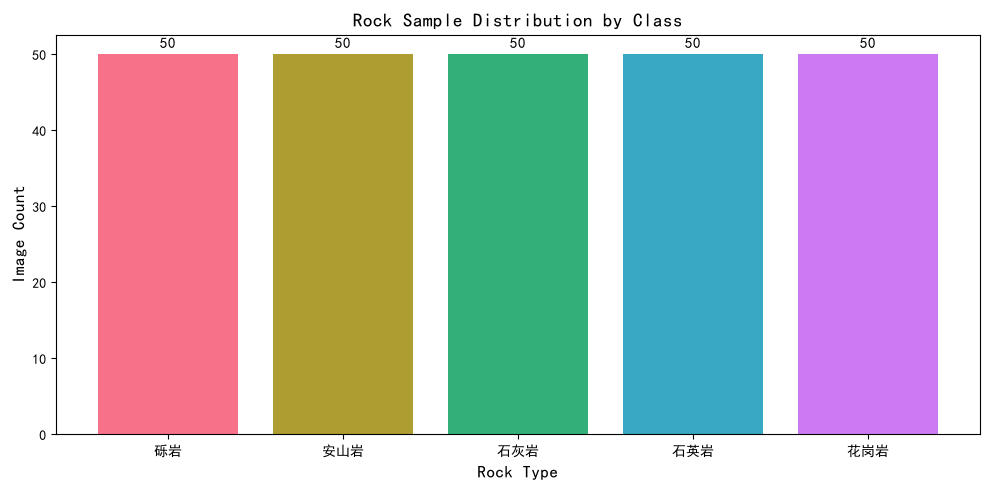

In [27]:
# Count samples per class
image_files = sorted(DATA_DIR.glob('*.jpg')) + sorted(DATA_DIR.glob('*.jpeg'))
print(f'Total images: {len(image_files)}')

class_counts = {}
for f in image_files:
    label = int(f.stem.split('_')[0])
    class_counts[label] = class_counts.get(label, 0) + 1

print('\nSamples per class:')
for label in range(NUM_CLASSES):
    print(f'  Class {label} - {CLASS_NAMES[label]}: {class_counts.get(label, 0)}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
labels = [CLASS_NAMES[i].split(' (')[0] for i in range(NUM_CLASSES)]
counts = [class_counts.get(i, 0) for i in range(NUM_CLASSES)]
colors = sns.color_palette('husl', NUM_CLASSES)
bars = ax.bar(labels, counts, color=colors)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count),
            ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Rock Type', fontsize=12)
ax.set_ylabel('Image Count', fontsize=12)
ax.set_title('Rock Sample Distribution by Class', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


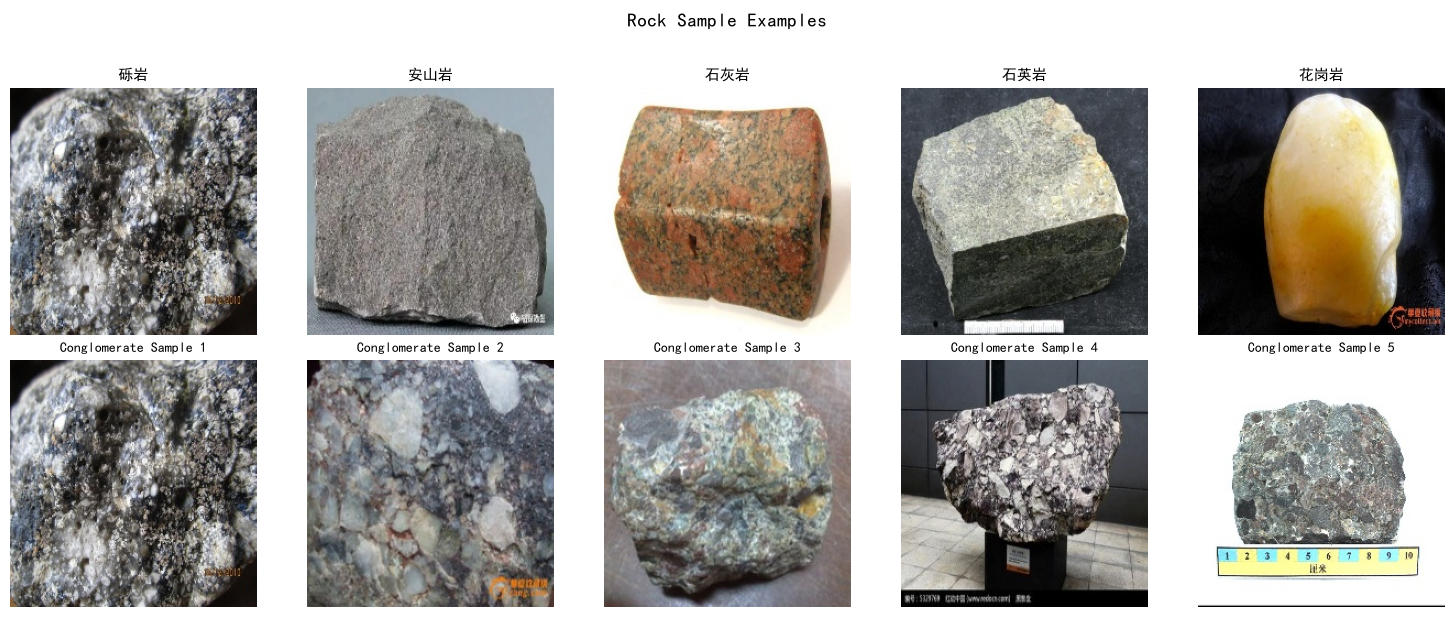

In [28]:
# Show sample images of each rock type
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
class_names_short = [CLASS_NAMES[i].split(' (')[0] for i in range(NUM_CLASSES)]

for label in range(NUM_CLASSES):
    class_files = [f for f in image_files if int(f.stem.split('_')[0]) == label]
    sample_file = class_files[0] if class_files else None
    ax = axes[label]
    if sample_file:
        img = Image.open(sample_file)
        ax.imshow(img)
        ax.set_title(class_names_short[label], fontsize=11)
    ax.axis('off')

# Right 5 show more samples of conglomerate
class_0_files = [f for f in image_files if int(f.stem.split('_')[0]) == 0]
for i, ax_idx in enumerate([5, 6, 7, 8, 9]):
    if i < len(class_0_files):
        img = Image.open(class_0_files[i])
        axes[ax_idx].imshow(img)
        axes[ax_idx].set_title(f'Conglomerate Sample {i+1}', fontsize=10)
        axes[ax_idx].axis('off')
    else:
        axes[ax_idx].axis('off')

plt.suptitle('Rock Sample Examples', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. 数据预处理

In [ ]:
# Preprocessing transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class RockDataset(Dataset):
    """Rock image dataset"""
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Read all files and labels
all_files = []
all_labels = []
for f in image_files:
    all_files.append(f)
    all_labels.append(int(f.stem.split('_')[0]))

print(f'Total samples: {len(all_files)}')

# Split: train 70% / val 20% / test 10% (stratified)
total = len(all_files)
test_count = total - int(0.7 * total) - int(0.2 * total)

train_val_idx, test_idx = train_test_split(
    np.arange(total), test_size=test_count / total,
    stratify=all_labels, random_state=42
)
train_val_labels = [all_labels[int(i)] for i in train_val_idx]
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=float(int(0.2*total)) / len(train_val_idx),
    stratify=train_val_labels, random_state=42
)

train_dataset = RockDataset([all_files[int(i)] for i in train_idx],
                            [all_labels[int(i)] for i in train_idx], transform=train_transform)
val_dataset = RockDataset([all_files[int(i)] for i in val_idx],
                          [all_labels[int(i)] for i in val_idx], transform=val_test_transform)
test_dataset = RockDataset([all_files[int(i)] for i in test_idx],
                           [all_labels[int(i)] for i in test_idx], transform=val_test_transform)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f'Training batches: {len(train_loader)}')


Total samples: 250
Train: 175 | Val: 50 | Test: 25
Training batches: 6


## 3. CNN 模型构建

Architecture: 3 conv layers + 2 fc layers, ReLU activation + MaxPool downsampling.

In [30]:
class RockCNN(nn.Module):
    """Rock Image Classification CNN

    Architecture:
    - Conv2d(3, 32, 3)+ReLU+MaxPool(2)  -> 32x64x64
    - Conv2d(32, 64, 3)+ReLU+MaxPool(2) -> 64x32x32
    - Conv2d(64, 128, 3)+ReLU+MaxPool(2) -> 128x16x16
    - FC(128*16*16, 128)+ReLU+Dropout(0.5)
    - FC(128, 5)
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super(RockCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                         # 64x64
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                         # 32x32
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                         # 16x16
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = RockCNN(NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print('\nModel structure:')
print(model)

Total parameters: 4,288,773
Trainable parameters: 4,288,773

Model structure:
RockCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): S

## 4. 模型训练

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
NUM_EPOCHS = 50

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

# Training loop
train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0
best_model_state = None

print('Starting training...')
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}] '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

print(f'\nTraining complete! Best val accuracy: {best_val_acc:.4f}')
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), OUTPUT_DIR / 'rock_cnn_model.pth')
    print('Model saved to output/rock_cnn_model.pth')
else:
    print('Warning: No best model saved (best_val_acc remained 0)')


Starting training...
Epoch [  1/50] Train Loss: 5.0051 | Train Acc: 0.3486 | Val Loss: 1.8820 | Val Acc: 0.4800
Epoch [  5/50] Train Loss: 1.1701 | Train Acc: 0.4514 | Val Loss: 1.1870 | Val Acc: 0.4400
Epoch [ 10/50] Train Loss: 0.9439 | Train Acc: 0.5886 | Val Loss: 0.8772 | Val Acc: 0.5600
Epoch [ 15/50] Train Loss: 0.8832 | Train Acc: 0.6686 | Val Loss: 0.7768 | Val Acc: 0.6200
Epoch [ 20/50] Train Loss: 0.7722 | Train Acc: 0.6971 | Val Loss: 0.9013 | Val Acc: 0.6600
Epoch [ 25/50] Train Loss: 0.6747 | Train Acc: 0.6971 | Val Loss: 1.0711 | Val Acc: 0.6200
Epoch [ 30/50] Train Loss: 0.6754 | Train Acc: 0.7314 | Val Loss: 0.7726 | Val Acc: 0.6800
Epoch [ 35/50] Train Loss: 0.4687 | Train Acc: 0.8229 | Val Loss: 0.7756 | Val Acc: 0.6600
Epoch [ 40/50] Train Loss: 0.4673 | Train Acc: 0.7714 | Val Loss: 0.8485 | Val Acc: 0.6200
Epoch [ 45/50] Train Loss: 0.4776 | Train Acc: 0.7943 | Val Loss: 0.7525 | Val Acc: 0.7000
Epoch [ 50/50] Train Loss: 0.4798 | Train Acc: 0.8400 | Val Loss: 0.6

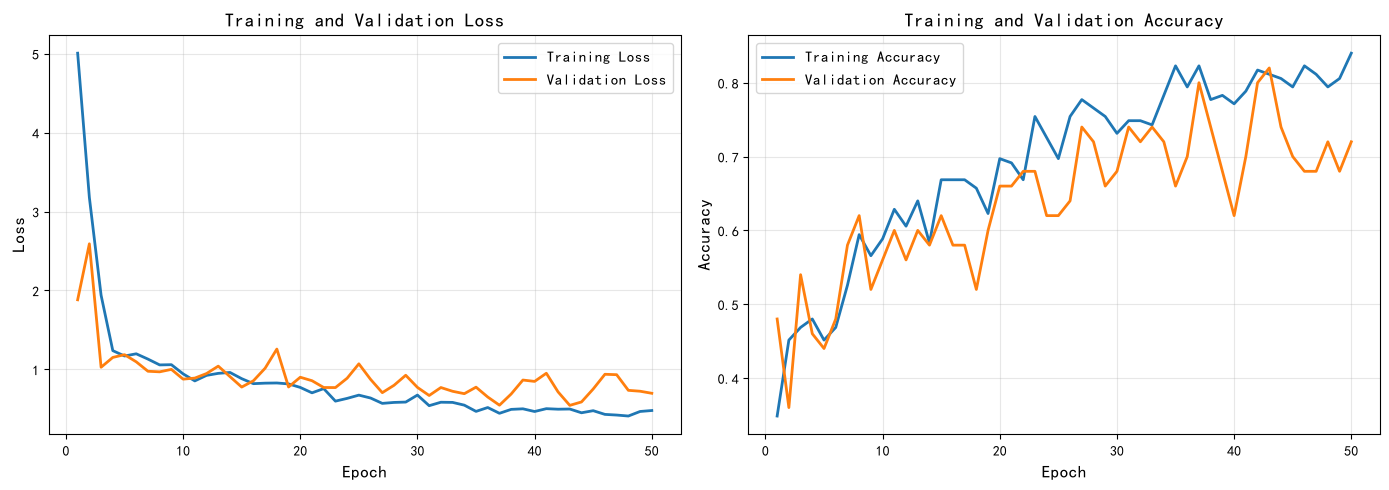

Final training accuracy: 0.8400
Final validation accuracy: 0.7200
Best validation accuracy: 0.8200


In [32]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, train_losses, label='Training Loss', linewidth=2)
ax1.plot(epochs_range, val_losses, label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, label='Training Accuracy', linewidth=2)
ax2.plot(epochs_range, val_accs, label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final training accuracy: {train_accs[-1]:.4f}')
print(f'Final validation accuracy: {val_accs[-1]:.4f}')
print(f'Best validation accuracy: {best_val_acc:.4f}')


## 5. 模型评估

In [37]:
# Test set evaluation
model.eval()
all_preds = []
all_labels_true = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_true.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels_true = np.array(all_labels_true)

test_acc = (all_preds == all_labels_true).mean()
print(f'\n========== Test Results ==========')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(all_labels_true, all_preds,
      target_names=class_names_short, digits=4))



========== Test Results ==========
Test Accuracy: 0.6800 (68.00%)

Classification Report:
              precision    recall  f1-score   support

          砾岩     0.5000    0.6000    0.5455         5
         安山岩     0.7143    1.0000    0.8333         5
         石灰岩     0.6667    0.4000    0.5000         5
         石英岩     0.6667    0.4000    0.5000         5
         花岗岩     0.8333    1.0000    0.9091         5

    accuracy                         0.6800        25
   macro avg     0.6762    0.6800    0.6576        25
weighted avg     0.6762    0.6800    0.6576        25



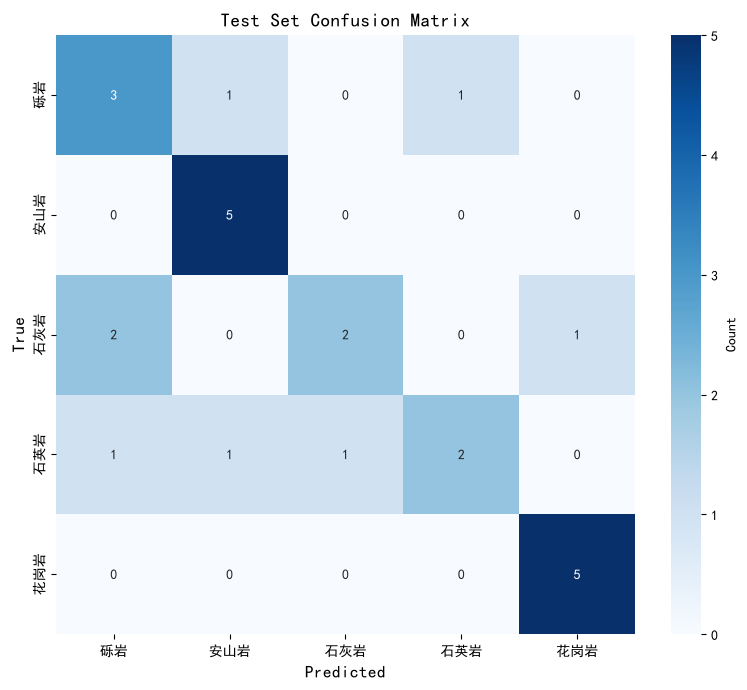

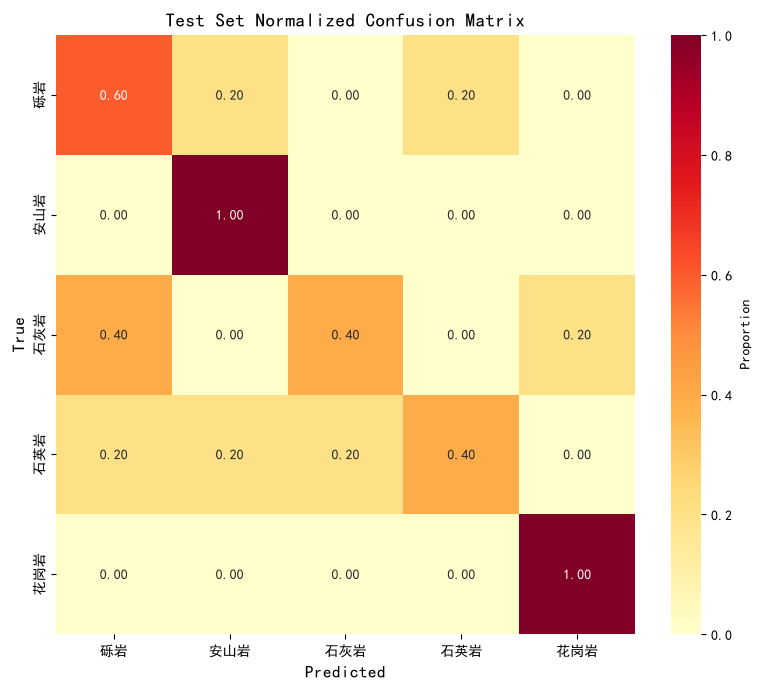

In [34]:
# Confusion matrix
cm = confusion_matrix(all_labels_true, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_short, yticklabels=class_names_short,
            cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Test Set Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names_short, yticklabels=class_names_short,
            vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Test Set Normalized Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_norm.png', dpi=150, bbox_inches='tight')
plt.show()


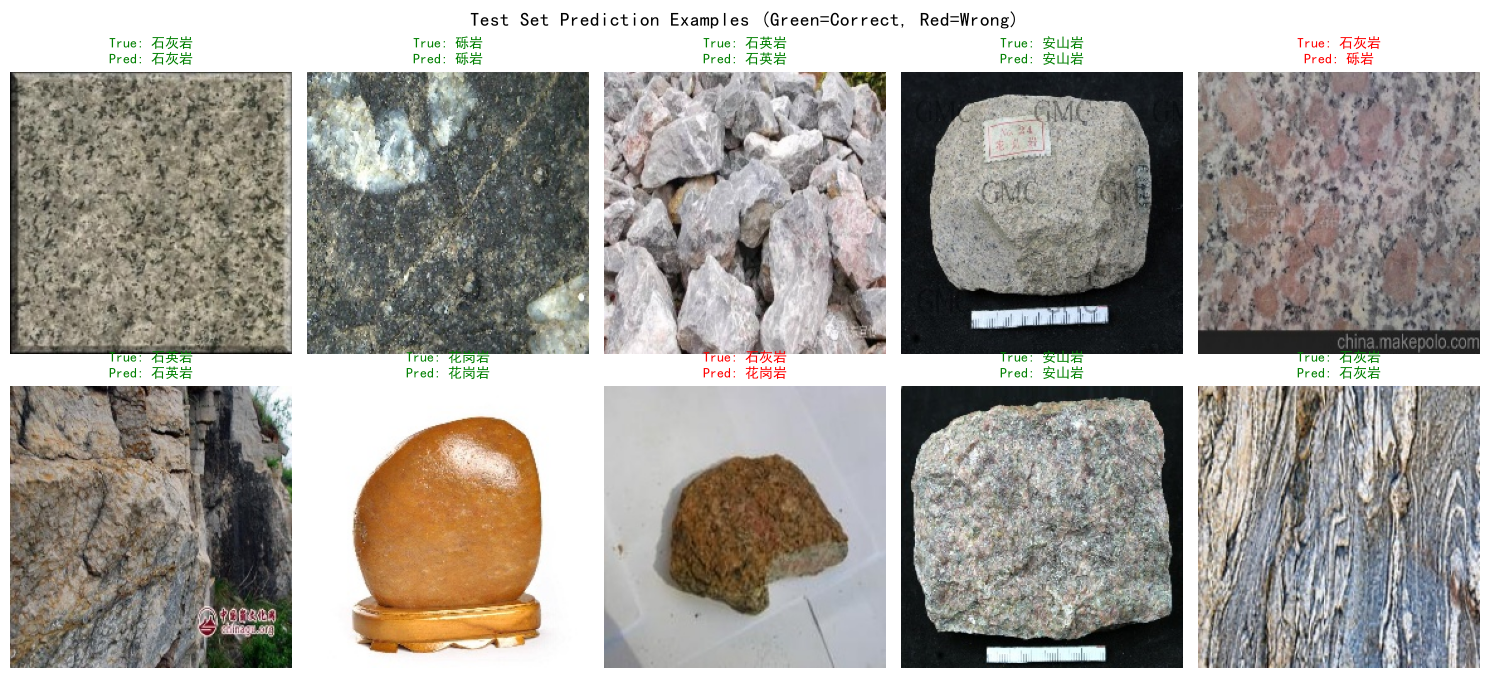

In [ ]:
# Visualize prediction results
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

test_files = [all_files[i] for i in test_idx]
sample_indices = random.sample(range(len(test_files)), min(10, len(test_files)))

for i, idx in enumerate(sample_indices):
    img = Image.open(test_files[idx]).convert('RGB')
    img_tensor = val_test_transform(img)
    if not isinstance(img_tensor, torch.Tensor):
        img_tensor = transforms.ToTensor()(img)
    img_tensor = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
    pred_label = pred.item()
    true_label = all_labels[int(test_idx[idx])]
    axes[i].imshow(Image.open(test_files[idx]))
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'True: {class_names_short[true_label]}\nPred: {class_names_short[pred_label]}',
                      color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Test Set Prediction Examples (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prediction_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 实验完成

All figures saved to `output/`:
- `class_distribution.png` — Class distribution
- `sample_images.png` — Sample examples
- `training_curve.png` — Training curves
- `confusion_matrix.png` — Confusion matrix
- `confusion_matrix_norm.png` — Normalized confusion matrix
- `prediction_examples.png` — Prediction examples
- `rock_cnn_model.pth` — Trained model weights
